<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/W03_MNIST_20_Epochs_23521013_Arief_Purnama_Muharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-3 Assignment: MNIST using Keras
____
Name: Arief Purnama Muharram
Student number: 23521013

In [ ]:
# [Install the Requirements]
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install tensorflow

     |████████████████████████████████| 462 kB 3.5 MB/s 


11501568/11490434 [==============================] - 0s 0us/step


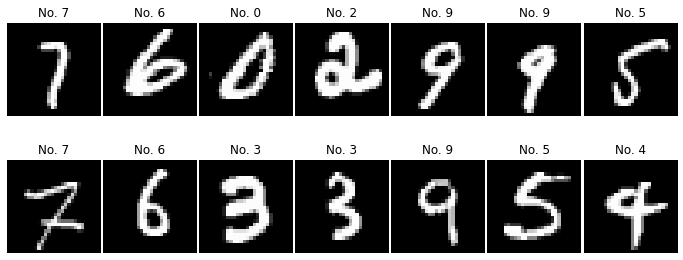

In [ ]:
# [Get the Dataset]

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets.mnist import load_data

(train_digits, train_labels), (test_digits, test_labels) = load_data()

# Create a 14 random numbers.
rand_num = np.random.randint(0, train_digits.shape[0], 14)

# Get sample images.
sample_digits = train_digits[rand_num]
sample_labels = train_labels[rand_num]

# Code to view the images
num_rows, num_cols = 2, 7
f, ax = plt.subplots(num_rows, num_cols, figsize=(12,5),
                     gridspec_kw={'wspace':0.03, 'hspace':0.01},
                     squeeze=True)

# Visualize the sample images.
for r in range(num_rows):
  for c in range(num_cols):
    image_index = (r * 7) + c
    ax[r,c].axis("off")
    ax[r,c].imshow(sample_digits[image_index], cmap='gray')
    ax[r,c].set_title('No. %d' % sample_labels[image_index])
plt.show()
plt.close()

In [ ]:
# [Data Pre-processing]

import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Define the image size.
image_height = train_digits.shape[1] # 28
image_width = train_digits.shape[2] # 28

# Set the image channels to 1 because we have only grayscale images.
num_channels = 1

# Re-shape the images data.
train_data = np.reshape(train_digits, (train_digits.shape[0], image_height, image_width, num_channels))
test_data = np.reshape(test_digits, (test_digits.shape[0], image_height, image_width, num_channels))

# Re-scale the image data to values between (0.0, 1.0)
train_data = train_data.astype('float32') / 255.0
test_data = test_data.astype('float32') / 255.0

# One-hot-encoding
num_classes = 10
train_labels_cat = to_categorical(train_labels, num_classes)
test_labels_cat = to_categorical(test_labels, num_classes)
train_labels_cat, test_labels_cat

# Create train and val data.
train_data, val_data, train_labels_cat, val_labels_cat = train_test_split(
    train_data, train_labels_cat, test_size=0.3, random_state=0
)

In [ ]:
# [Build the Model]

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_model():
  model = Sequential()
  model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', 
                   padding='same', input_shape=(image_height, image_width, 
                                                num_channels)))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', 
                   padding='same'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', 
                   padding='same'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Flatten())
  # Densely connected layers
  model.add(Dense(128, activation='relu'))
  # Output layer
  model.add(Dense(num_classes, activation='softmax'))
  # Compile with adam optimizer & categorical_crossentropy loss function
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

model = build_model()
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 64)          36928     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 3, 3, 64)         0

In [ ]:
# [Train the Model]

results = model.fit(train_data, train_labels_cat, epochs=20, batch_size=64,
                    validation_data=(val_data, val_labels_cat))

Epoch 1/20
657/657 [==============================] - 65s 100ms/step - loss: 0.0025 - accuracy: 0.9991 - val_loss: 0.0721 - val_accuracy: 0.9889
Epoch 2/20
657/657 [==============================] - 65s 99ms/step - loss: 0.0038 - accuracy: 0.9988 - val_loss: 0.0724 - val_accuracy: 0.9892
Epoch 3/20
657/657 [==============================] - 65s 99ms/step - loss: 0.0032 - accuracy: 0.9990 - val_loss: 0.0629 - val_accuracy: 0.9891
Epoch 4/20
657/657 [==============================] - 65s 99ms/step - loss: 0.0020 - accuracy: 0.9993 - val_loss: 0.0771 - val_accuracy: 0.9891
Epoch 5/20
657/657 [==============================] - 65s 99ms/step - loss: 0.0036 - accuracy: 0.9991 - val_loss: 0.0763 - val_accuracy: 0.9888
Epoch 6/20
657/657 [==============================] - 65s 98ms/step - loss: 0.0048 - accuracy: 0.9986 - val_loss: 0.0513 - val_accuracy: 0.9916
Epoch 7/20
657/657 [==============================] - 65s 99ms/step - loss: 5.2671e-04 - accuracy: 0.9998 - val_loss: 0.0590 - val_accu

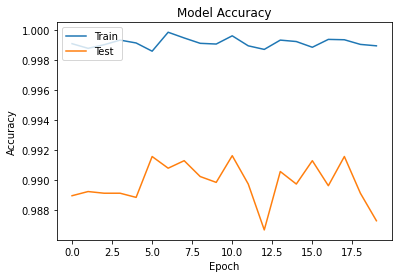

In [ ]:
# [Summarize History for Accuracy]

import matplotlib.pyplot as plt

plt.plot(results.history['accuracy'])
plt.plot(results.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

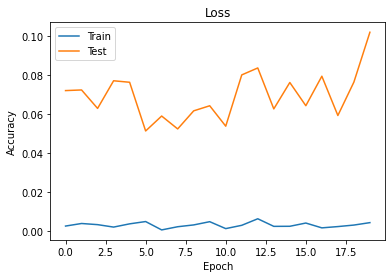

In [ ]:
# [Summarize History for Loss]

import matplotlib.pyplot as plt

plt.plot(results.history['loss'])
plt.plot(results.history['val_loss'])
plt.title('Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
# [Evaluate the Models]

test_loss, test_accuracy = model.evaluate(test_data, test_labels_cat, batch_size=64)
print('Test loss: %.4f Accuracy: %.4f' % (test_loss, test_accuracy))

157/157 [==============================] - 4s 26ms/step - loss: 0.0633 - accuracy: 0.9901
Test loss: 0.0633 Accuracy: 0.9901
